<a href="https://colab.research.google.com/github/hayashichiho/simclr/blob/master/SimCRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR (Simple Framework for Contrastive Learning of Visual Representations)

## 目次
1. [全体設定とライブラリのインポート](#scrollTo=sYiCxF4p0xV5)
2. [データセットの読み込みとData Augmentationの可視化](#scrollTo=X37sLIIr7Wbl)
3. [SimCLRモデルの構築 (Encoder & Projection Head)](#scrollTo=xscfEoTVCFLF)
4. [損失関数 (NT-Xent Loss) の実装](#scrollTo=9uuBxMhiXjTJ)
5. [事前学習 (Pre-training) の実行](#scrollTo=AuZOgb0ndtyI)
6. [Linear Evaluationによる表現学習の評価とスクラッチ学習との比較](#scrollTo=Mrr7wkHrZaBj)

## 1. 全体設定とライブラリのインポート

**ライブラリーのインストール**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.models.resnet import ResNet, Bottleneck
from torch.optim.optimizer import Optimizer
import math
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import shutil

**全体の設定**

In [2]:
DATASET_NAME = "STL10" # "STL10" または "CIFAR10" を指定
OPTIMIZER_NAME = "AdamW" # "LARS" または "AdamW"
BASE_RESNET_MODEL = "resnet18" # "resnet18" または "resnet50"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Target Dataset: {DATASET_NAME}")
print(f"Optimizer: {OPTIMIZER_NAME}")

Using device: cpu
Target Dataset: STL10
Optimizer: AdamW


**データのダウンロード**

In [3]:
USE_GOOGLE_DRIVE = True
drive_file_path_stl10 = '/content/drive/MyDrive/Colab Notebooks/stl10_binary.tar.gz' # Drive内にあるデータのパスを入力
drive_file_path_cifar10 = '/content/drive/MyDrive/Colab Notebooks/cifar-10-binary.tar.gz' # Drive内にあるデータのパスを入力

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    # Colabローカルの保存先ディレクトリを作成
    os.makedirs('./data', exist_ok=True)
    if DATASET_NAME == "STL10":
        local_file_path = './data/stl10_binary.tar.gz'
        drive_file_path = drive_file_path_stl10
    elif DATASET_NAME == "CIFAR10":
        local_file_path = './data/cifar-10-binary.tar.gz'
        drive_file_path = drive_file_path_cifar10

    # ローカルにまだファイルがなければコピーを実行
    if not os.path.exists(local_file_path):
        print("Google Driveからローカルへ圧縮データをコピー中")
        shutil.copy2(drive_file_path, local_file_path)
        print("コピー完了！")
    else:
        print("既にローカルにデータが準備されています．")

Mounted at /content/drive
Google Driveからローカルへ圧縮データをコピー中
コピー完了！


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. データセットの読み込みとData Augmentationの可視化

以下の変換をランダムに組み合わせる：
* **RandomResizedCrop**: 画像の一部をランダムに切り出してリサイズ（構図の変化）
* **RandomHorizontalFlip**: 50%の確率で画像の水辺向きを逆転
* **ColorJitter**: 明るさ，コントラスト，彩度，色相のランダムな変更（色情報のドロップアウト）
* **RandomGrayscale**: ランダムな確率での白黒化
* **GaussianBlur**: ガウシアンブラーによるぼかし処理（高周波成分の除去）


In [5]:
class TransformsSimCLR:
    def __init__(self, size, gauss_p):
        s = 1
        color_jitter = torchvision.transforms.ColorJitter(
            0.8 * s, 0.8 * s, 0.8 * s, 0.2 * s
        )

        kernel_size = int(0.1 * size)
        if kernel_size % 2 == 0:
            kernel_size += 1
        gaussian_blur = torchvision.transforms.GaussianBlur(kernel_size=kernel_size)

        self.train_transform = torchvision.transforms.Compose(
            [
                torchvision.transforms.RandomResizedCrop(size=size),
                torchvision.transforms.RandomHorizontalFlip(),
                torchvision.transforms.RandomApply([color_jitter], p=0.8),
                torchvision.transforms.RandomGrayscale(p=0.2),
                torchvision.transforms.RandomApply([gaussian_blur], p=gauss_p),
                torchvision.transforms.ToTensor(),
            ]
        )

        self.test_transform = torchvision.transforms.Compose(
            [
                torchvision.transforms.Resize(size=size),
                torchvision.transforms.ToTensor(),
            ]
        )

    def __call__(self, x):
        # 1枚の入力画像 x から，2つの異なる拡張画像（正例ペア）を生成して返す
        return self.train_transform(x), self.train_transform(x)

**データの読み込み**

In [6]:
if DATASET_NAME == "STL10":
    IMAGE_SIZE = 96
    train_dataset = torchvision.datasets.STL10(
        root='./data', split='unlabeled', download=True,
        transform=TransformsSimCLR(size=IMAGE_SIZE, gauss_p=0.5)
    )
elif DATASET_NAME == "CIFAR10":
    IMAGE_SIZE = 32
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True,
        transform=TransformsSimCLR(size=IMAGE_SIZE, gauss_p=0.0)
    )

**データローダの作成**

In [7]:
batch_size = 256
num_workers = os.cpu_count()
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
    pin_memory=True
)

print(f"データセットの総画像数: {len(train_dataset)} 枚")
print(f"1エポックあたりのバッチ数: {len(train_loader)} ステップ")

データセットの総画像数: 100000 枚
1エポックあたりのバッチ数: 390 ステップ


### データ拡張（Data Augmentation）の可視化
上段が元画像，中段と下段がそれに対応するデータ拡張結果です．

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


中段のテンソルサイズ: torch.Size([256, 3, 96, 96])
下段のテンソルサイズ: torch.Size([256, 3, 96, 96])


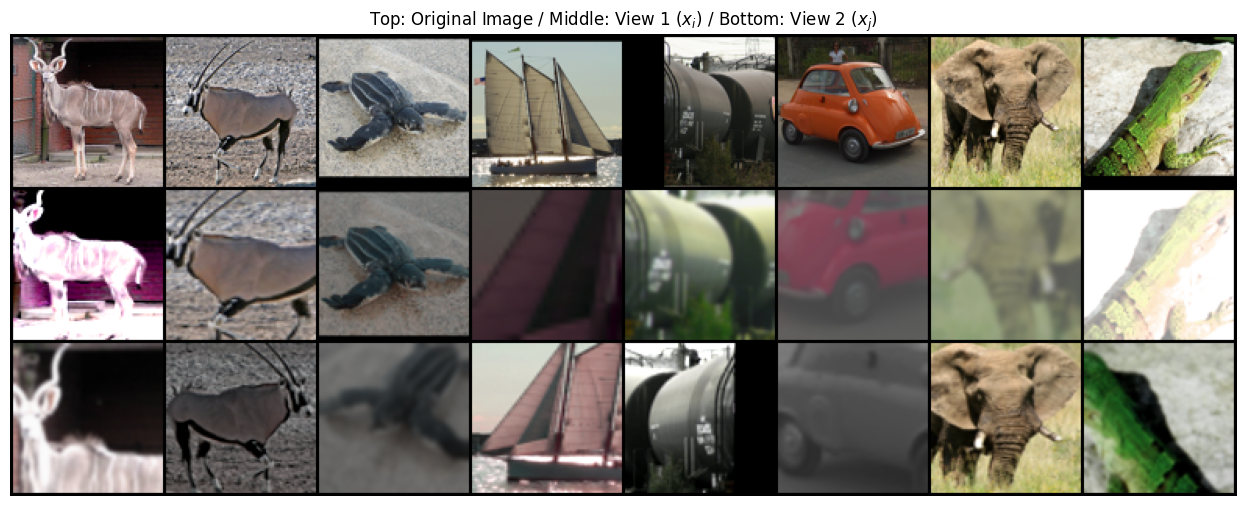

In [8]:
def show_augmentations_with_original(dataset, num_pairs=8):
    # 現在データセットに設定されている変換モジュール（TransformsSimCLR）を退避
    transform_module = dataset.transform

    # 一時的にデータセットの変換を解除し，生の画像(PIL)を取り出せるようにする
    dataset.transform = None

    orig_list, v1_list, v2_list = [], [], []

    for i in range(num_pairs):
        # 生の画像を取得
        raw_img, _ = dataset[i]

        # test_transform で元の画像をテンソル化（リサイズのみ，色などの変化なし）
        orig_tensor = transform_module.test_transform(raw_img)
        # train_transform で2つの異なる強力なデータ拡張をかける
        v1_tensor = transform_module.train_transform(raw_img)
        v2_tensor = transform_module.train_transform(raw_img)

        orig_list.append(orig_tensor)
        v1_list.append(v1_tensor)
        v2_list.append(v2_tensor)

    # 元の変換モジュールをデータセットに戻す
    dataset.transform = transform_module

    # テンソルを結合
    orig_tensor_batch = torch.stack(orig_list)
    v1_tensor_batch = torch.stack(v1_list)
    v2_tensor_batch = torch.stack(v2_list)

    # 3段に結合
    combined_samples = torch.cat([orig_tensor_batch, v1_tensor_batch, v2_tensor_batch], dim=0)

    # make_grid を使って，3行 x num_pairs列 に並べる
    grid_img = torchvision.utils.make_grid(combined_samples, nrow=num_pairs, padding=2, normalize=False)

    plt.figure(figsize=(16, 6))
    plt.imshow(grid_img.permute(1, 2, 0).numpy())
    plt.title(f"Top: Original Image / Middle: View 1 ($x_i$) / Bottom: View 2 ($x_j$)")
    plt.axis("off")
    plt.show()

# 試しに1バッチ取り出してみる（テンソルサイズの確認用）
(x_i, x_j), _ = next(iter(train_loader))
print(f"中段のテンソルサイズ: {x_i.shape}") # [256, 3, 96, 96]
print(f"下段のテンソルサイズ: {x_j.shape}") # [256, 3, 96, 96]

# 可視化関数の実行
show_augmentations_with_original(train_dataset, num_pairs=8)

## 3. SimCLRモデルの構築 (Encoder & Projection Head)

SimCLRのモデル構造は，以下の2つから構成される．
- 画像から特徴（$h$）を抽出する **「エンコーダ（Backbone）」**
- 特徴を対照学習用の空間（$z$）に変換する **「プロジェクションヘッド（Projection Head）」**

まずはエンコーダの準備を行う．ベースは `ResNet` を使用する．

### ResNetの入力層（Stem）のカスタマイズ
ここで定義する `modify_resnet_model` 関数は，PyTorch (`torchvision`) に標準で用意されているResNetを，**小さな画像（CIFAR-10やSTL-10）向けに最適化する**ための関数である．

標準のResNetは，ImageNetのような大きな画像（224x224など）を想定して作られている．
そのため，最初の層（Stem層）で「7x7の大きな畳み込み」と「Max Pooling」を使い，一気に画像の解像度を下げてしまう．
しかし，今回のような小さな画像で同じことをすると，重要な空間情報が早い段階で潰れてしまい，学習がうまくいきません．

そこで，以下のような改造を施す：
1. **最初の巨大な畳み込みを，小さな `3x3` の畳み込み（stride=1）に変更する**
2. **情報ロスを防ぐため，最初の `Max Pooling` 層を削除（Identityで素通り）する**

### ResNetのカスタマイズ

In [9]:
def modify_resnet_model(model, *, cifar_stem=True, v1=True):
    assert isinstance(model, ResNet), "model must be a ResNet instance"
    if cifar_stem:
        conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        nn.init.kaiming_normal_(conv1.weight, mode="fan_out", nonlinearity="relu")
        model.conv1 = conv1
        model.maxpool = nn.Identity()
    if v1:
        for l in range(2, 5):
            layer = getattr(model, "layer{}".format(l))
            block = list(layer.children())[0]
            if isinstance(block, Bottleneck):
                assert block.conv1.kernel_size == (1, 1) and block.conv1.stride == (
                    1,
                    1,
                )
                assert block.conv2.kernel_size == (3, 3) and block.conv2.stride == (
                    2,
                    2,
                )
                assert block.conv2.dilation == (
                    1,
                    1,
                ), "Currently, only models with dilation=1 are supported"
                block.conv1.stride = (2, 2)
                block.conv2.stride = (1, 1)
    return model

### ResNetを取得する関数

In [10]:
def get_resnet(name, weights=None):
    resnets = {
        "resnet18": torchvision.models.resnet18(weights=weights),
        "resnet50": torchvision.models.resnet50(weights=weights),
    }
    if name not in resnets.keys():
        raise KeyError(f"{name} is not a valid ResNet version")
    return resnets[name]

### `SimCLR` クラス：ネットワーク全体の構築

このクラスでは， **「エンコーダ（$f(\cdot)$）」** と， **「プロジェクションヘッド（$g(\cdot)$）」** を繋ぎ合わせる．

* **表現 $h$ (Representation)**：エンコーダの出力．
* **プロジェクション $z$ (Projection)**：プロジェクションヘッドの出力．事前学習の際にContrastive Loss（NT-Xent Loss）を計算するため**だけ**に使用し，学習が終わったらこのヘッドは破棄する．

プロジェクションヘッドは `Linear -> BatchNorm -> ReLU -> Linear` というシンプルな多層パーセプトロン（MLP）で構成する．

In [11]:
class SimCLR(nn.Module):
    def __init__(self, encoder, projection_dim, n_features):
        super(SimCLR, self).__init__()

        self.encoder = encoder
        self.n_features = n_features

        # ResNetの最後の全結合層を無効化（素通りさせる）
        self.encoder.fc = nn.Identity() # WRITE ME

        # プロジェクションヘッド (Linear -> BatchNorm -> ReLU -> Linear の構成)
        self.projector = nn.Sequential(
            nn.Linear(self.n_features, self.n_features, bias=False),
            nn.BatchNorm1d(self.n_features), # WRITE ME
            nn.ReLU(inplace=True), # WRITE ME
            nn.Linear(self.n_features, projection_dim, bias=False)
        )

    def forward(self, x_i, x_j):
        # 2つのビュー(x_i, x_j)から表現(h_i, h_j)を抽出
        h_i = self.encoder(x_i) # WRITE ME
        h_j = self.encoder(x_j) # WRITE ME

        # 表現(h_i, h_j)をプロジェクション(z_i, z_j)へ変換
        z_i = self.projector(h_i) # WRITE ME
        z_j = self.projector(h_j) # WRITE ME

        return h_i, h_j, z_i, z_j

## 4. 損失関数 (NT-Xent Loss) の実装

$$\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

バッチ内の画像に対して以下の手順で実装する．
1. 全画像の総当たりでコサイン類似度を計算（Temperatureパラメータ $\tau$ で割ってスケーリング）．
2. 各画像にとっての「正例（Positive）」の類似度を抜き出し，配列の**一番左（インデックス0）** に配置．
3. 残りの「負例（Negative）」の類似度を，その右側に並べて結合．

このように配列を作ると，**「常にインデックス0が正解（一番類似度が高くなってほしい相手）になるような多クラス分類問題」** に変換することができる．そのため，Pytorch標準の `CrossEntropyLoss` を使って最適化することができる．

### NT-Xent Lossの実装

In [12]:
class NT_XentLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5):
        super(NT_XentLoss, self).__init__()
        self.batch_size = batch_size
        self.temperature = temperature

        # 負例だけを抽出するためのブールマスクを事前に作成
        self.mask = self._get_correlated_mask().requires_grad_(False)
        self.criterion = nn.CrossEntropyLoss(reduction="sum") # WRITE ME
        self.similarity_f = nn.CosineSimilarity(dim=2) # WRITE ME

    def _get_correlated_mask(self):
        # 2N x 2N の True で埋まった行列を作成
        N = 2 * self.batch_size
        mask = torch.ones((N, N), dtype=torch.bool)

        # 1. 対角成分（全く同じ画像自身）を False にして除外
        mask = mask.fill_diagonal_(0)

        # 2. 正例ペア（例：z_i[0] と z_j[0]）の場所も False にして除外
        # これにより，このマスクを通すと純粋な「負例」だけが残る
        for i in range(self.batch_size):
            mask[i, self.batch_size + i] = 0
            mask[self.batch_size + i, i] = 0
        return mask

    def forward(self, z_i, z_j):
        N = 2 * self.batch_size
        device = z_i.device

        # 2つのバッチを縦に結合し，(2N, D) のテンソルにする
        z = torch.cat((z_i, z_j), dim=0)

        # 全ペアのコサイン類似度行列 (2N x 2N) を計算し，温度パラメータで割る
        sim = self.similarity_f(z.unsqueeze(1), z.unsqueeze(0)) / self.temperature # WRITE ME

        # --- 正例 (Positive) の抽出 ---
        # sim_i_j: 前半と後半のペアの類似度
        # sim_j_i: 後半と前半のペアの類似度
        sim_i_j = torch.diag(sim, self.batch_size)
        sim_j_i = torch.diag(sim, -self.batch_size)

        # 縦に並べて (2N, 1) の形状にする
        positive_samples = torch.cat((sim_i_j, sim_j_i), dim=0).reshape(N, 1)

        # --- 負例 (Negative) の抽出 ---
        # 事前に作ったマスクを使って，負例だけの類似度を取り出す (2N, 2N - 2)
        # ※ 2N 個の中から，自身(1)と正例ペア(1)を除いた 2N-2 個が負例
        negative_samples = sim[self.mask.to(device)].reshape(N, -1)

        # --- 結合と分類問題化 ---
        # 正例を列の「一番左（インデックス0）」に，残りを負例として結合 (2N, 2N - 1)
        logits = torch.cat((positive_samples, negative_samples), dim=1)

        # 正例はすべてインデックス0に配置したので，正解ラベルは「すべて0」になる
        labels = torch.zeros(N, dtype=torch.long).to(device) # WRITE ME

        # 交差エントロピー誤差を計算し，バッチ数で割る
        loss = self.criterion(logits, labels) / N # WRITE ME
        return loss

### LARS オプティマイザ

SimCLRの論文では，一般的な `SGD` や `Adam` ではなく，**LARS (Layer-wise Adaptive Rate Scaling)** という少し特殊な最適化手法が使われている．

### なぜLARSが必要なのか？
対照学習（Contrastive Learning）は，**「バッチサイズが大きければ大きいほど，比較対象となる負例（Negative）が増えるため精度が上がる」** という特徴を持っている．実際，SimCLRの論文では `8192` といった巨大なバッチサイズで学習を行っている．

巨大なバッチサイズで学習する場合，それに比例して学習率（Learning Rate）も大きく設定する必要がある（Linear Scaling Rule）．
しかし，学習率を極端に大きくすると，特に学習の序盤で勾配が爆発し，学習が崩壊してしまうという問題が発生する．

### 層ごとに学習率を自動調整する仕組み
LARSは，この問題を解決するために **「層（Layer）ごとに，重みの大きさと勾配の大きさの比率（Trust Ratio）を計算し，学習率を層ごとに自動でスケーリングする」** というアプローチをとる．
これにより，巨大なバッチサイズと巨大な学習率を用いても，安定してモデルを学習させることができる．

###  `get_lars_param_groups` 関数
ディープラーニングの学習において，**バイアス（Bias）やバッチ正規化（BatchNorm）のパラメータにWeight Decay（重み減衰）やLARSのスケーリングをかけると，逆に精度が悪化する** ことが知られている．そのため，パラメータ名に `bias` や `bn` が含まれるものを意図的に除外する処理を入れている．

In [13]:
class LARS(Optimizer):
    def __init__(self, params, lr, momentum=0.9, weight_decay=1e-4, trust_coef=0.001):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay, trust_coef=trust_coef)
        super(LARS, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            weight_decay = group['weight_decay']
            momentum = group['momentum']
            trust_coef = group['trust_coef']
            # このグループが LARS(Layer Adaptation) を適用すべきかどうか
            layer_adaptation = group.get('layer_adaptation', True)

            for p in group['params']:
                if p.grad is None:
                    continue

                param = p.data
                grad = p.grad.data
                state = self.state[p]

                # Weight Decay の適用
                if weight_decay != 0:
                    grad.add_(param, alpha=weight_decay)

                # Trust Ratio (学習率のスケーリング) の計算
                if layer_adaptation:
                    w_norm = torch.norm(param)
                    g_norm = torch.norm(grad)

                    trust_ratio = 1.0
                    if w_norm > 0 and g_norm > 0:
                        trust_ratio = trust_coef * w_norm / g_norm
                else:
                    # BatchNormやBiasの場合はスケーリングしない(1.0)
                    trust_ratio = 1.0

                scaled_lr = group['lr'] * trust_ratio

                # Momentumの計算と重みの更新
                if 'momentum_buffer' not in state:
                    next_v = state['momentum_buffer'] = torch.zeros_like(p.data)
                else:
                    next_v = state['momentum_buffer']

                next_v.mul_(momentum).add_(grad, alpha=scaled_lr)
                param.sub_(next_v)

def get_lars_param_groups(model, lr, weight_decay=1e-4):
    regularized = []
    excluded = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        # 名前に 'bias' や 'bn' (BatchNorm) が含まれているかチェック
        if 'bias' in name or 'bn' in name or 'batchnorm' in name:
            excluded.append(param)
        else:
            regularized.append(param)

    return [
        # Conv層などの重み: LARSとWeight Decayを適用
        {'params': regularized, 'lr': lr, 'weight_decay': weight_decay, 'layer_adaptation': True},
        # BatchNormやBias: LARSとWeight Decayを無効化
        {'params': excluded, 'lr': lr, 'weight_decay': 0.0, 'layer_adaptation': False}
    ]


## 5. 事前学習 (Pre-training) の実行

### 学習ループで実行されること
1. **バッチの取得**: データローダーから，Data Augmentationがかかったペアを取得．
2. **フォワードパス**: 画像をエンコーダに通して特徴表現（$h$）を抽出し，さらにプロジェクションヘッドに通して対照学習用のベクトル（$z$）に変換．
3. **損失の計算**: NT-Xent Lossを用いて，「同じ元画像から来たペア」のベクトル同士を近づけ，「違う画像から来たペア」を遠ざけるように誤差を計算．
4. **重みの更新**: 誤差をもとに，オプティマイザがエンコーダとプロジェクションヘッドのパラメータ（重み）を更新．

### 学習率のスケジューリング (Cosine Annealing)
学習の序盤は大きな学習率で大胆に重みを更新し，学習の終盤に向かってコサインカーブを描くように滑らかに学習率をゼロに近づけていくことで，最終的な精度を底上げする．

### 事前学習前の準備

In [14]:
# エンコーダーの作成
encoder = get_resnet(BASE_RESNET_MODEL)
n_features = encoder.fc.in_features # ResNet18の場合は512, ResNet50の場合は2048

# CIFAR-10など画像サイズが小さい場合はResNetをカスタマイズ
if IMAGE_SIZE <= 32:
    print("Applying CIFAR stem modification (replacing 7x7 conv & removing maxpool)")
    encoder = modify_resnet_model(encoder, cifar_stem=True)

# SimCLRモデルのインスタンス化
model = SimCLR(encoder=encoder, projection_dim=64, n_features=n_features).to(device) # WRITE ME

# 損失関数のインスタンス化
criterion = NT_XentLoss(batch_size=batch_size, temperature=0.5).to(device) # WRITE ME

# チェックポイント保存の設定
save_every_n_epochs = 10  # 10エポックごとに保存する
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# オプティマイザの切り替え
if OPTIMIZER_NAME == "LARS":
    base_lr = 1.0 # LARS用の大きな学習率
    param_groups = get_lars_param_groups(model, lr=base_lr, weight_decay=1e-6)
    optimizer = LARS(param_groups, lr=base_lr)
elif OPTIMIZER_NAME == "AdamW":
    base_lr = 3e-4 # AdamW用の標準的な学習率
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-4)
else:
    raise ValueError("Invalid optimizer name")

### 学習ループ

In [15]:
epochs = 1

In [16]:
# Cosine Annealingの適用
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader) * epochs)

print("=== SimCLR 事前学習スタート ===")
for epoch in range(epochs):
    model.train() # 訓練モードにする
    total_loss = 0 # 訓練データに対する損失

    for step, ((x1, x2), _) in enumerate(train_loader):
        x1, x2 = x1.to(device), x2.to(device) # テンソルをGPUに移動

        # フォワードパス
        h1, h2, z1, z2 = model(x1, x2) # WRITE ME

        # NT-Xent Loss (Step 4で定義したもの)
        loss = criterion(z1, z2) # WRITE ME

        # バックプロパゲーションと更新
        optimizer.zero_grad()
        loss.backward()

        # AdamW の場合のみ，勾配爆発を防ぐためのクリッピングを適用
        if OPTIMIZER_NAME == "AdamW":
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step() # パラメータの更新
        scheduler.step() # 学習率の更新

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # 現在の学習率を取得して表示
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.2f}, LR: {current_lr:.6f}")

    # 指定したエポック間隔，または最後のエポックの時に保存を実行
    if (epoch + 1) % save_every_n_epochs == 0 or (epoch + 1) == epochs:
        checkpoint_path = os.path.join(checkpoint_dir, f"simclr_{DATASET_NAME}_{BASE_RESNET_MODEL}_{OPTIMIZER_NAME}_epoch{epoch+1}.pth")

        # モデルの重みを保存
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  💾 チェックポイントを保存しました: {checkpoint_path}")

print("=== 事前学習完了 ===")

=== SimCLR 事前学習スタート ===


KeyboardInterrupt: 

## 6. 線形評価 (Linear Evaluation) と比較実験

### 線形評価
学習済みのエンコーダ（ResNet）の**重みを固定（Freeze）**し，その後ろに**1層だけの全結合層（Linear層）** を追加する．
そして，少数のラベル付きデータを使って，この「最後の1層だけ」を学習させて分類精度を測る．

### 学習済みモデルの使用有無

True: さきほど自分で学習したモデルを使用

False: 100 Epochs学習済みの公開モデルをダウンロードして使用

In [17]:
USE_MY_OWN_MODEL = False

### データローダーの準備

In [18]:
# 1. スクラッチ学習用 (データ拡張あり)
scratch_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(IMAGE_SIZE),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
])

# 2. 特徴量キャッシュ用 (データ拡張なし・リサイズのみ)
cache_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(IMAGE_SIZE),
    torchvision.transforms.ToTensor(),
])

if DATASET_NAME == "STL10":
    scratch_train_ds = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=scratch_transform)
    scratch_test_ds = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=cache_transform)
    cache_train_ds = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=cache_transform)
    cache_test_ds = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=cache_transform)
elif DATASET_NAME == "CIFAR10":
    scratch_train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=scratch_transform)
    scratch_test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=cache_transform)
    cache_train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=cache_transform)
    cache_test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=cache_transform)

scratch_train_loader = torch.utils.data.DataLoader(scratch_train_ds, batch_size=256, shuffle=True, drop_last=False, num_workers=num_workers)
scratch_test_loader = torch.utils.data.DataLoader(scratch_test_ds, batch_size=256, shuffle=False, drop_last=False, num_workers=num_workers)

cache_train_loader = torch.utils.data.DataLoader(cache_train_ds, batch_size=512, shuffle=False)
cache_test_loader = torch.utils.data.DataLoader(cache_test_ds, batch_size=512, shuffle=False)

### 比較実験：スクラッチ学習
まずはベースライン（基準）となるモデルの学習関数を定義する．
一切の事前学習を行わず，ランダムな初期重みの状態から，画像とラベルを使ってResNetの「すべての層」を学習させる．

In [19]:
class FullModelClassifier(nn.Module):
    def __init__(self, backbone, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        h = self.backbone(x)
        return self.fc(h)

def train_scratch_model(epochs=15):
    print(f"\n--- スクラッチ学習の開始 (全層フル学習: {epochs} Epochs) ---")

    encoder = get_resnet(BASE_RESNET_MODEL)
    if IMAGE_SIZE <= 32: encoder = modify_resnet_model(encoder, cifar_stem=True)
    encoder.fc = nn.Identity()

    scratch_model = FullModelClassifier(encoder).to(device)
    optimizer = optim.AdamW(scratch_model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    best_acc = 0.0
    for epoch in range(epochs):
        scratch_model.train()
        for x, y in scratch_train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = scratch_model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

        scratch_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in scratch_test_loader:
                x, y = x.to(device), y.to(device)
                logits = scratch_model(x)
                preds = torch.argmax(logits, dim=1)
                total += y.size(0)
                correct += (preds == y).sum().item()

        acc = 100.0 * correct / total
        if acc > best_acc: best_acc = acc
        print(f"  Epoch [{epoch+1}/{epochs}] Test Accuracy: {acc:.2f}% (Best: {best_acc:.2f}%)")

    return best_acc, scratch_model.backbone

### 特徴量の抽出とキャッシュ
線形評価ではエンコーダの重みを固定する．
つまり，同じ画像を入力すれば，何エポック回しても**常に出力される特徴量（512次元のベクトル）は同じ**になる．

学習ループを回す前に，あらかじめ全データをエンコーダに通して「512次元の特徴量配列（NumPy）」として保存（キャッシュ）しておきます．
これにより，学習時は重い画像処理（CNN）を一切行わず，単純な行列計算（Logistic Regression）だけで済むため，**100エポックの学習が高速で完了する**．

ここでは比較対象として，**② ImageNetの大量のラベル付きデータで事前学習された強力なモデル**と，**③ SimCLR (表現 $h$ / 512次元)**，**④ SimCLR (プロジェクション $z$ / 64次元)** から特徴量を抽出する．

**特徴量を抽出しキャッシュする関数**

In [20]:
def extract_features(loader, target_encoder, target_projector=None):
    target_encoder.eval()
    if target_projector is not None:
        target_projector.eval()

    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            # エンコーダで表現(h)を抽出
            h = target_encoder(x).flatten(start_dim=1)

            # プロジェクタが指定されていれば，さらに通してプロジェクション(z)にする
            if target_projector is not None:
                h = target_projector(h)

            features.append(h.cpu().numpy())
            labels.append(y.numpy())

    return np.concatenate(features), np.concatenate(labels)

**モデルの準備**

In [21]:
# 1. スクラッチモデル (比較用: 学習前の初期重み)
scratch_encoder = get_resnet(BASE_RESNET_MODEL)
if IMAGE_SIZE <= 32:
    scratch_encoder = modify_resnet_model(scratch_encoder, cifar_stem=True)
scratch_encoder.fc = nn.Identity()
scratch_encoder = scratch_encoder.to(device)

# 2. ImageNet事前学習済みモデル (強力な教師あり学習済みの重みを使用)
pretrained_encoder = get_resnet(BASE_RESNET_MODEL, weights="DEFAULT")
if IMAGE_SIZE <= 32:
    pretrained_encoder = modify_resnet_model(pretrained_encoder, cifar_stem=True)
pretrained_encoder.fc = nn.Identity()
pretrained_encoder = pretrained_encoder.to(device)

# 3. SimCLRモデルの準備 (フラグに応じて自作か公開かを切り替え)
if USE_MY_OWN_MODEL:
    print("  -> 【自作のSimCLRモデル】を評価に使用します．")
    target_simclr_encoder = model.encoder
    simclr_model_name = "My SimCLR"
else:
    if DATASET_NAME == "STL10":
        print("  -> 【公開済みSimCLRモデル(100 Epochs)】を評価に使用します．")
        print("     (ダウンロード中...)")
        if BASE_RESNET_MODEL == "resnet18":
            checkpoint_url = "https://github.com/Spijkervet/SimCLR/releases/download/1.1/checkpoint_100.tar"
        else:
            checkpoint_url = "https://github.com/Spijkervet/SimCLR/releases/download/1.2/checkpoint_100.tar"
        checkpoint_path = "checkpoint_100.tar"

        if not os.path.exists(checkpoint_path):
            urllib.request.urlretrieve(checkpoint_url, checkpoint_path)

        # 公開モデル用のエンコーダーを準備
        target_simclr_encoder = get_resnet(BASE_RESNET_MODEL)
        if IMAGE_SIZE <= 32: target_simclr_encoder = modify_resnet_model(target_simclr_encoder, cifar_stem=True)
        target_simclr_encoder.fc = nn.Identity()

        downloaded_simclr = SimCLR(encoder=target_simclr_encoder, projection_dim=64, n_features=512)
        try:
            # ダウンロードした重みをロード
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
            state_dict = checkpoint.get('state_dict', checkpoint)
            downloaded_simclr.load_state_dict(state_dict, strict=False)
            target_simclr_encoder = downloaded_simclr.encoder.to(device)
            target_simclr_projector = downloaded_simclr.projector.to(device)
            print("     重みロード完了！")
        except Exception as e:
            print(f"     ⚠️ 公開モデルのロードに失敗しました: {e}")

        simclr_model_name = "Public SimCLR (100 Epochs)"
    else:
      print("  -> CIFAR-10には公開モデルはありません．評価をスキップします．")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 64.4MB/s]


  -> 【公開済みSimCLRモデル(100 Epochs)】を評価に使用します．
     (ダウンロード中...)
     重みロード完了！


**特徴量のキャッシュ化**

In [22]:
print("\n--- 特徴量の抽出（キャッシュ）を開始 ---")

print("  -> [1/3] ImageNet事前学習モデルから抽出中...")
train_x_pretrained, train_y = extract_features(cache_train_loader, pretrained_encoder)
test_x_pretrained, test_y = extract_features(cache_test_loader, pretrained_encoder)

print(f"  -> [2/3] {simclr_model_name} モデル (表現 h: 512次元) から抽出中...")
train_x_simclr_h, _ = extract_features(cache_train_loader, target_simclr_encoder)
test_x_simclr_h, _ = extract_features(cache_test_loader, target_simclr_encoder)

print(f"  -> [3/3] {simclr_model_name} モデル (プロジェクション z: 64次元) から抽出中...")
train_x_simclr_z, _ = extract_features(cache_train_loader, target_simclr_encoder, target_simclr_projector)
test_x_simclr_z, _ = extract_features(cache_test_loader, target_simclr_encoder, target_simclr_projector)

print(f"  抽出完了! 訓練用特徴量の形状 -> h: {train_x_simclr_h.shape} , z: {train_x_simclr_z.shape}")


--- 特徴量の抽出（キャッシュ）を開始 ---
  -> [1/3] ImageNet事前学習モデルから抽出中...
  -> [2/3] Public SimCLR (100 Epochs) モデル (表現 h: 512次元) から抽出中...
  -> [3/3] Public SimCLR (100 Epochs) モデル (プロジェクション z: 64次元) から抽出中...
  抽出完了! 訓練用特徴量の形状 -> h: (5000, 512) , z: (5000, 64)


### 線形評価 (Linear Evaluation) の実行と比較実験

最後に，抽出した特徴量だけを入力として，1層のシンプルな線形分類器（Logistic Regression）を学習させる．

ここでは，SimCLRの性能と，論文内で報告されている内容を検証するため，**合計4つのパターン**で分類精度を比較する．

1. **スクラッチ学習**: 5000枚の画像とラベルで，ゼロから全層を学習させたモデル **（基準となる下限）**
2. **ImageNet事前学習**: 100万枚以上のラベル付き画像で学習した最強クラスのモデル **（目標となる上限）**
3. **SimCLR (表現 $h$ / 512次元)**: ラベルなしで学習したエンコーダの出力をそのまま使用 **（論文の本筋）**
4. **SimCLR (プロジェクション $z$ / 64次元)**: プロジェクションヘッドを通した後の出力を使用

**💡 実験のポイント：表現 $h$ vs プロジェクション $z$**
SimCLRのモデルは「エンコーダ」と「プロジェクションヘッド」の2段構成になっている．
論文の重要な発見の一つに，**「学習が終わった後，プロジェクションヘッドを通した出力($z$)よりも，その手前のエンコーダの出力($h$)をそのまま使った方が分類精度が高い」** というものがある．

これは，プロジェクションヘッドが「対照学習（色や構図の激しい変化を同一視する）」のタスクに特化しすぎるあまり，元の画像が持っていた細かい情報の一部まで削ぎ落としてしまうことが理由である．

**分類器のみのシンプルなモデル**

In [23]:
class LogisticRegression(nn.Module):
    def __init__(self, n_features=512, n_classes=10):
        super().__init__()
        self.fc = nn.Linear(n_features, n_classes)

    def forward(self, x):
        return self.fc(x)

**線形評価関数**

In [24]:
def train_linear_classifier(train_x, train_y, test_x, test_y, name, epochs=100):
    print(f"\n--- {name} の線形評価を開始 ({epochs} Epochs) ---")
    # 入力されたデータの形に合わせて線形層の大きさを決定
    n_features = train_x.shape[1]

    # TensorDataset と DataLoader を作成
    train_ds = torch.utils.data.TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
    test_ds = torch.utils.data.TensorDataset(torch.from_numpy(test_x), torch.from_numpy(test_y))

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=256, shuffle=False)

    # モデルは1層のLinearのみ
    clf_model = LogisticRegression(n_features=n_features, n_classes=10).to(device)

    # SGD + CosineAnnealing
    optimizer = optim.SGD(clf_model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    best_acc = 0.0

    for epoch in range(epochs):
        clf_model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = clf_model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

        scheduler.step()

        clf_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = clf_model(x)
                preds = torch.argmax(logits, dim=1)
                total += y.size(0)
                correct += (preds == y).sum().item()

        acc = 100.0 * correct / total
        if acc > best_acc:
            best_acc = acc

        # 20エポックごとに表示
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] Test Accuracy: {acc:.2f}% (Best: {best_acc:.2f}%)")

    return best_acc

**比較実験の実行**

In [25]:
# ① スクラッチは画像から全層フル学習 (時間がかかるので15エポック程度が目安)
scratch_epochs = 15
acc_scratch, scratch_encoder = train_scratch_model(epochs=scratch_epochs)

# ② 事前学習済みはキャッシュから最終層のみ学習 (100エポック)
eval_epochs = 100
acc_pretrained = train_linear_classifier(train_x_pretrained, train_y, test_x_pretrained, test_y, "ImageNet事前学習", epochs=eval_epochs)
if DATASET_NAME == "STL10":
    acc_simclr_h = train_linear_classifier(train_x_simclr_h, train_y, test_x_simclr_h, test_y, f"{simclr_model_name} (表現 h)", epochs=eval_epochs)
    acc_simclr_z = train_linear_classifier(train_x_simclr_z, train_y, test_x_simclr_z, test_y, f"{simclr_model_name} (プロジェクション z)", epochs=eval_epochs)
elif DATASET_NAME == "CIFAR10":
    acc_simclr = 0.0

print("\n==========================================")
print("🎯 最終結果の比較 (Linear Evaluation - Best Accuracy)")
print("==========================================")
print(f"  1. スクラッチ学習 ({scratch_epochs} epochs)                   : {acc_scratch:.2f} %")
print(f"  2. ImageNet事前学習                             : {acc_pretrained:.2f} %")
print(f"  3. SimCLR 事前学習 (表現 h: 512次元)            : {acc_simclr_h:.2f} %")
print(f"  4. SimCLR 事前学習 (プロジェクション z: 64次元) : {acc_simclr_z:.2f} %")
print("==========================================")


--- スクラッチ学習の開始 (全層フル学習: 15 Epochs) ---
  Epoch [1/15] Test Accuracy: 18.48% (Best: 18.48%)
  Epoch [2/15] Test Accuracy: 34.90% (Best: 34.90%)
  Epoch [3/15] Test Accuracy: 35.26% (Best: 35.26%)
  Epoch [4/15] Test Accuracy: 28.91% (Best: 35.26%)
  Epoch [5/15] Test Accuracy: 40.16% (Best: 40.16%)
  Epoch [6/15] Test Accuracy: 42.38% (Best: 42.38%)
  Epoch [7/15] Test Accuracy: 47.96% (Best: 47.96%)
  Epoch [8/15] Test Accuracy: 48.74% (Best: 48.74%)
  Epoch [9/15] Test Accuracy: 39.20% (Best: 48.74%)
  Epoch [10/15] Test Accuracy: 38.45% (Best: 48.74%)
  Epoch [11/15] Test Accuracy: 36.44% (Best: 48.74%)
  Epoch [12/15] Test Accuracy: 34.21% (Best: 48.74%)
  Epoch [13/15] Test Accuracy: 40.35% (Best: 48.74%)
  Epoch [14/15] Test Accuracy: 46.74% (Best: 48.74%)
  Epoch [15/15] Test Accuracy: 50.06% (Best: 50.06%)

--- ImageNet事前学習 の線形評価を開始 (100 Epochs) ---
  Epoch [1/100] Test Accuracy: 65.61% (Best: 65.61%)
  Epoch [20/100] Test Accuracy: 77.40% (Best: 77.67%)
  Epoch [40/100] Test A

### 獲得した特徴表現の可視化 (t-SNE)
抽出した512次元の特徴量を，t-SNEを用いて2次元に圧縮して散布図にプロットする．
色は実際のクラスラベルを表している．
ラベルを与えずに学習したにもかかわらず，同じクラスの画像が自然と集まっている（クラスタリングされている）ことがわかる．

--- 1. Scratch Learning (15 Epochs) のt-SNE可視化を実行中... ---


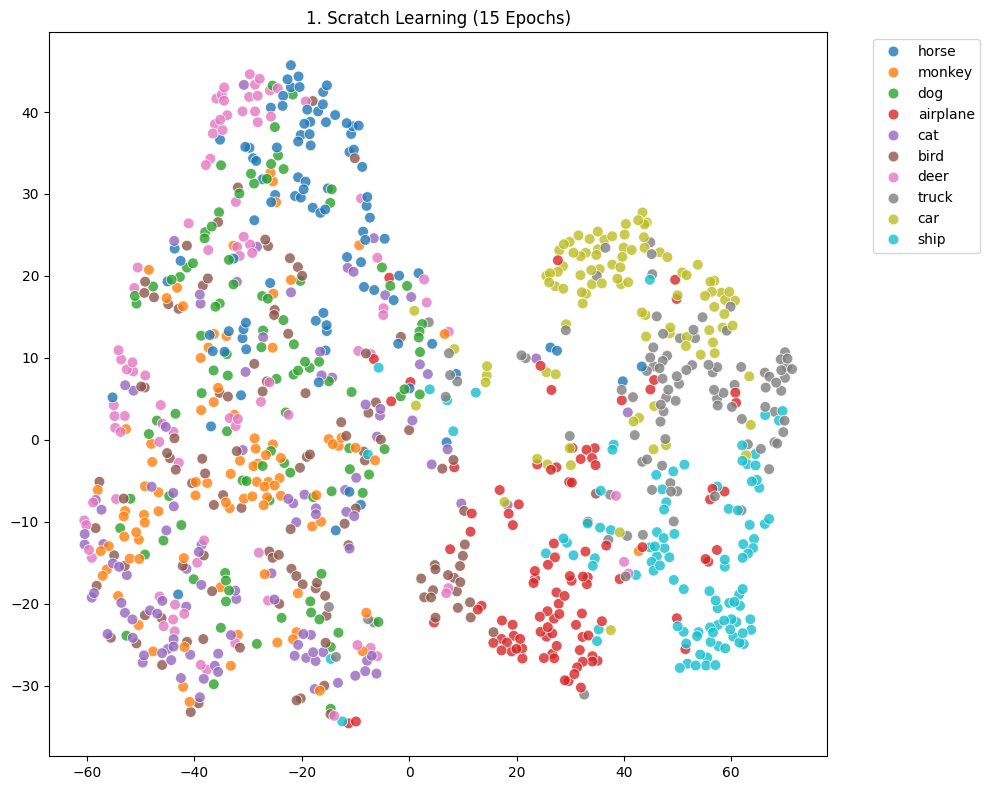

--- 2. ImageNet Pre-trained のt-SNE可視化を実行中... ---


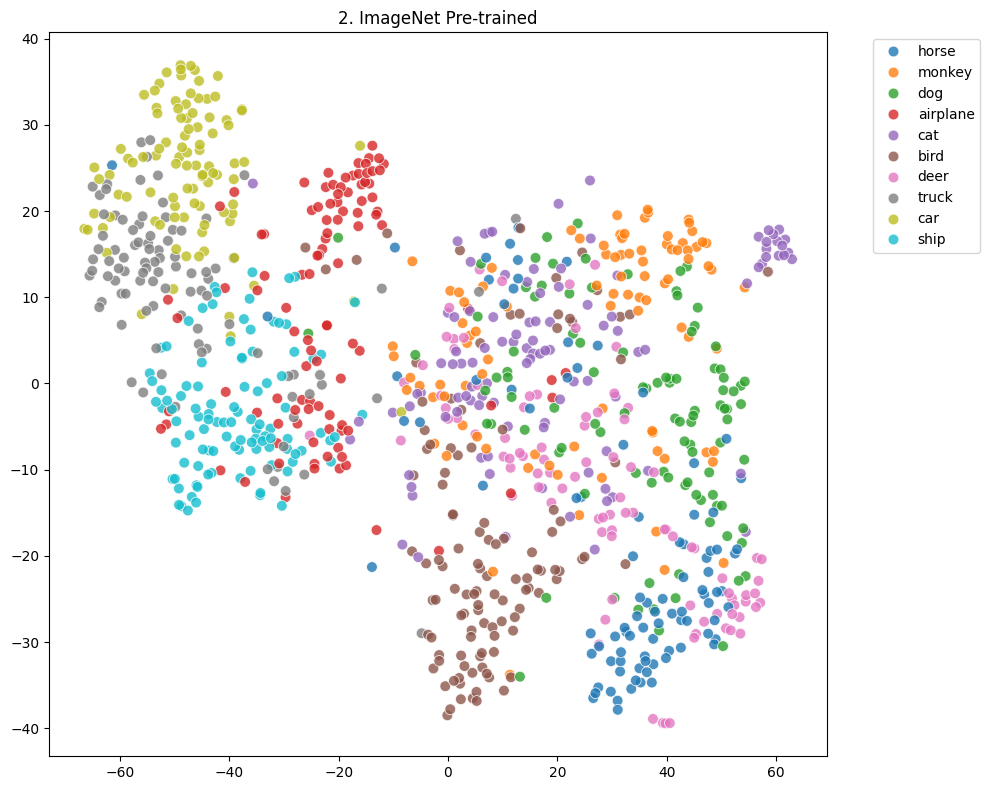

--- 3. Public SimCLR (100 Epochs) (Representation h) のt-SNE可視化を実行中... ---


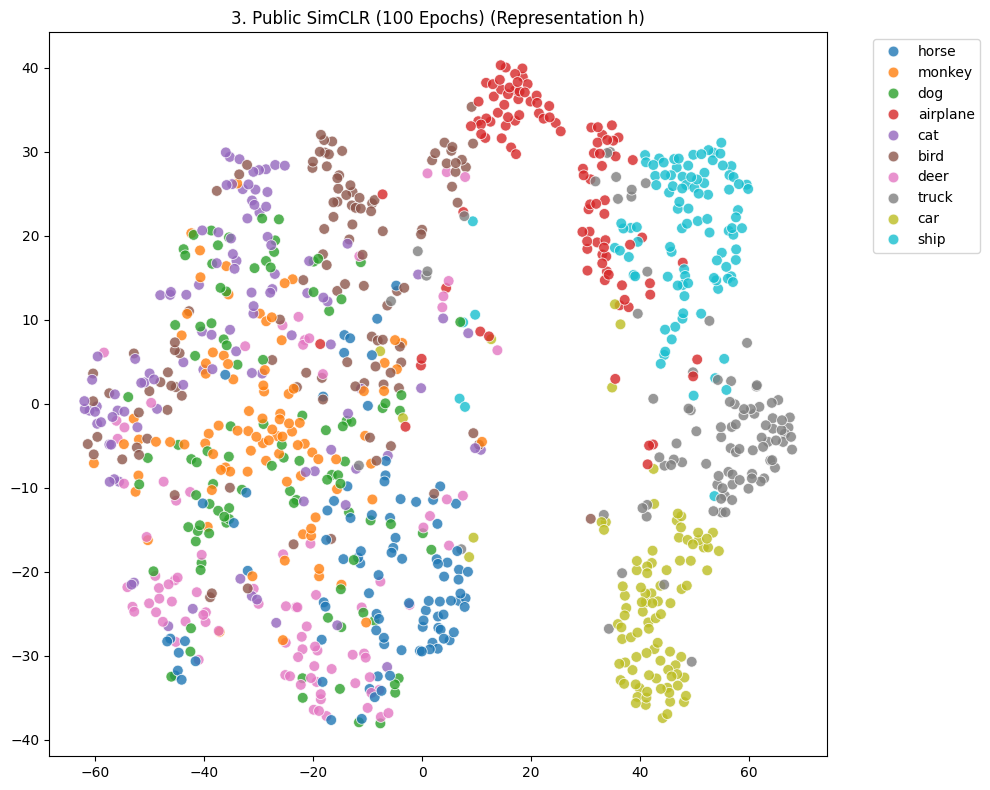

--- 4. Public SimCLR (100 Epochs) (Projection z) のt-SNE可視化を実行中... ---


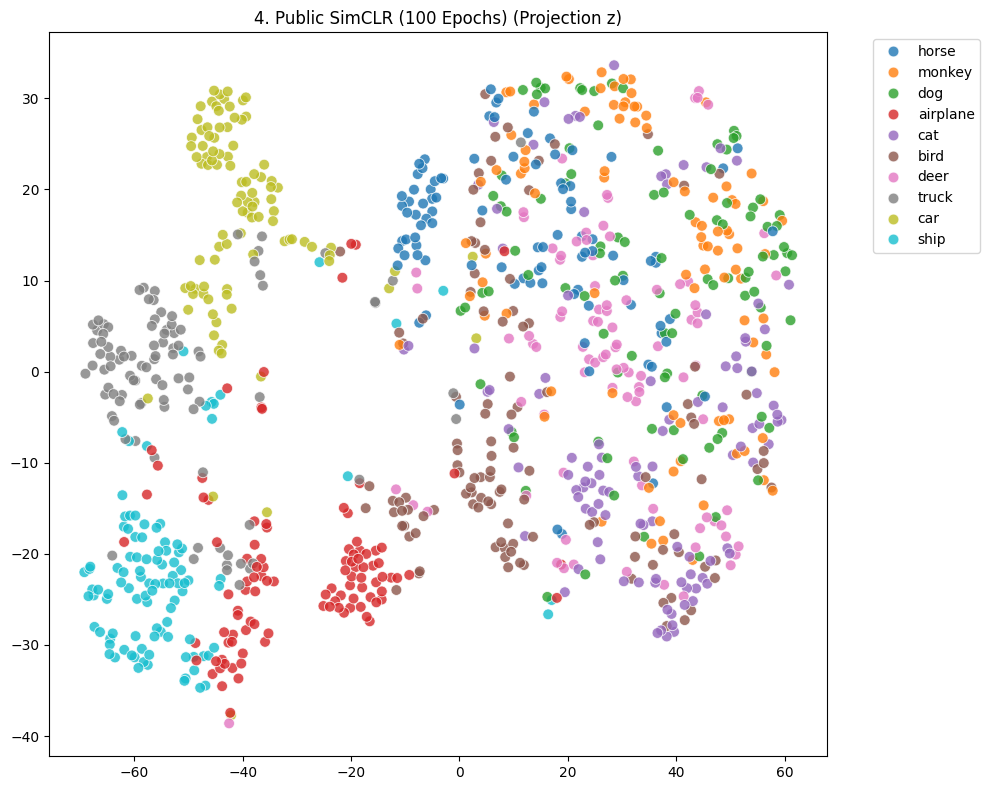

In [26]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

def plot_tsne(features, labels, title, n_samples=1000):
    """
    抽出済みの特徴量配列を受け取り，t-SNEで2次元に圧縮して散布図を描画する関数
    """
    print(f"--- {title} のt-SNE可視化を実行中... ---")

    # 計算速度と視認性のためサンプル数を絞る
    features_subset = features[:n_samples]
    labels_subset = labels[:n_samples]

    # 次元数が大きい場合のみ，事前にPCAで次元圧縮してノイズを落とす
    if features_subset.shape[1] > 30:
        pca = PCA(n_components=30, random_state=42)
        features_pca = pca.fit_transform(features_subset)
    else:
        features_pca = features_subset

    # t-SNEの実行
    tsne = TSNE(
        n_components=2,
        perplexity=20,
        init='pca',
        max_iter=2000,
        random_state=42
    )
    features_2d = tsne.fit_transform(features_pca)

    # STL-10のクラス名
    class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

    # 描画
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=features_2d[:, 0], y=features_2d[:, 1],
        hue=[class_names[lbl] for lbl in labels_subset],
        palette="tab10", legend="full", alpha=0.8, s=60
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ------------------------------------------
# 各モデルの特徴空間を順番に可視化して比較
# ------------------------------------------
# 1. スクラッチ学習 (15 Epochs)
test_x_scratch, _ = extract_features(cache_test_loader, scratch_encoder)
plot_tsne(test_x_scratch, test_y, "1. Scratch Learning (15 Epochs)")

# 2. ImageNet事前学習
plot_tsne(test_x_pretrained, test_y, "2. ImageNet Pre-trained")

# 3. SimCLR (表現 h: 512次元)
plot_tsne(test_x_simclr_h, test_y, f"3. {simclr_model_name} (Representation h)")

# 4. SimCLR (プロジェクション z: 64次元)
plot_tsne(test_x_simclr_z, test_y, f"4. {simclr_model_name} (Projection z)")